In [14]:
import os

os.environ["MKL_THREADING_LAYER"] = "GNU"  # fix: libmkl_intel_thread undefined symbol in this env

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [15]:
def gpt_params(seq_len, vocab_size, d_model, num_heads, num_layers):
    """Given GPT config calculate total number of parameters"""
    ffw_size = 4 * d_model  # in GPT the number of intermediate features is always 4*d_model
    # token and position embeddings
    embeddings = d_model * vocab_size + d_model * seq_len
    # transformer blocks
    attention = 3 * d_model**2 + 3 * d_model  # weights and biases
    attproj = d_model**2 + d_model
    ffw = d_model * (ffw_size) + ffw_size
    ffwproj = ffw_size * d_model + d_model
    layernorms = 2 * 2 * d_model
    # dense
    ln_f = 2 * d_model
    dense = d_model * vocab_size  # note: no bias here
    # note: embeddings are not included in the param count!
    total_params = num_layers * (attention + attproj + ffw + ffwproj + layernorms) + ln_f + dense
    return total_params


def estimate_flops(N, L, H, Q, T):
    return 6 * N + 12 * L * H * Q * T

In [16]:
def generate_figures(ratio_considered, model_config):
    L = model_config["n_layer"]
    H = model_config["n_head"]
    E0 = model_config["n_embd"]
    Q0 = E0 // H
    T = 1024

    flops_list = []
    for r in ratio_considered:
        tmp_Q = Q0 // r
        tmp_E = tmp_Q * H

        N = gpt_params(
            seq_len=T,
            vocab_size=50257,
            d_model=tmp_E,
            num_heads=H,
            num_layers=L,
        )

        flops = estimate_flops(N=N, L=L, H=H, Q=tmp_Q, T=T)

        flops_list.append(flops)
    return np.array(flops_list)

In [17]:
vocab_size = 50257
seq_len = 1024

# Small:
small_config = dict(n_layer=12, n_head=12, n_embd=768)
# Medium:
medium_config = dict(n_layer=24, n_head=16, n_embd=1024)
# Large:
large_config = dict(n_layer=36, n_head=20, n_embd=1280)
# Extreme Large:
xlarge_config = dict(n_layer=48, n_head=25, n_embd=1600)

In [18]:
ratio_considered = [1, 2, 4, 8, 16, 32, 64]

flops_array = generate_figures(ratio_considered, small_config)

normalized_flops_array = flops_array[0] / flops_array

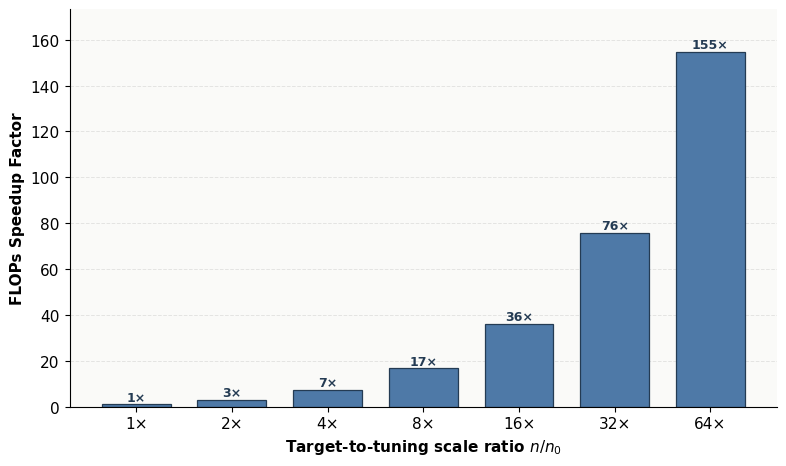

In [19]:
import matplotlib.pyplot as plt
import numpy as np

positions = np.arange(len(ratio_considered))
colors = ["#4E79A7"] * len(ratio_considered)

plt.rcParams.update(
    {
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

fig, ax = plt.subplots(figsize=(8, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAF8")

bars = ax.bar(
    positions,
    normalized_flops_array,
    width=0.72,
    color=colors,
    edgecolor="#243B53",
    linewidth=0.9,
)

for x, bar, value in zip(positions, bars, normalized_flops_array):
    ax.text(
        x,
        bar.get_height() + 0.3,
        f"{value:.0f}×",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#243B53",
    )

ax.set_xticks(positions)
ax.set_xticklabels([f"{r}×" for r in ratio_considered])

ax.set_xlabel("Target-to-tuning scale ratio $n/n_0$", fontweight="bold")
ax.set_ylabel("FLOPs Speedup Factor", fontweight="bold")

ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, normalized_flops_array.max() * 1.12)

plt.tight_layout()

plt.savefig("gpt2-small-flops.pdf")

plt.show()

## MLP FLOPs Analysis

Estimate compute savings from tuning a compressed proxy MLP instead of the full-width target model (ForestCoverType config: `input_dim=54`, `hidden_dim=2000`, `output_dim=7`, `num_layers=4`).

In [20]:
def mlp_matmul_params(input_dim, hidden_dim, output_dim, num_layers):
    """Count weight-matrix parameters (no biases) for FLOPs estimation."""
    # Input layer
    params = input_dim * hidden_dim
    # Hidden layers
    params += (num_layers - 2) * hidden_dim * hidden_dim
    # Output layer (MuReadout)
    params += hidden_dim * output_dim
    return params


def estimate_mlp_flops(input_dim, hidden_dim, output_dim, num_layers):
    """Estimate FLOPs per sample for MLP training (forward + backward).
    Uses the same 6N convention as GPT: 2 FLOPs per weight in forward,
    4 in backward (grad w.r.t. input + grad w.r.t. weight).
    """
    N = mlp_matmul_params(input_dim, hidden_dim, output_dim, num_layers)
    return 6 * N

In [21]:
# ForestCoverType config (see dataset_configs.py: N=500, k=4 → target hidden_dim=2000)
mlp_config = dict(input_dim=54, hidden_dim=2000, output_dim=7, num_layers=4)

ratio_considered_mlp = [1, 2, 4, 8, 16, 32, 64]

mlp_flops_list = []
for r in ratio_considered_mlp:
    tmp_hidden = mlp_config["hidden_dim"] // r
    flops = estimate_mlp_flops(
        input_dim=mlp_config["input_dim"],
        hidden_dim=tmp_hidden,
        output_dim=mlp_config["output_dim"],
        num_layers=mlp_config["num_layers"],
    )
    mlp_flops_list.append(flops)

mlp_flops_array = np.array(mlp_flops_list)
normalized_mlp_flops_array = mlp_flops_array[0] / mlp_flops_array

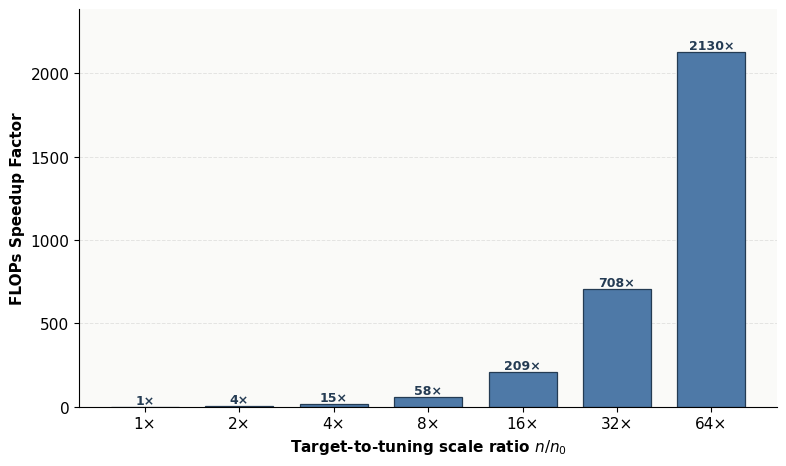

In [22]:
positions = np.arange(len(ratio_considered_mlp))
colors = ["#4E79A7"] * len(ratio_considered_mlp)

plt.rcParams.update(
    {
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

fig, ax = plt.subplots(figsize=(8, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAF8")

bars = ax.bar(
    positions,
    normalized_mlp_flops_array,
    width=0.72,
    color=colors,
    edgecolor="#243B53",
    linewidth=0.9,
)

for x, bar, value in zip(positions, bars, normalized_mlp_flops_array):
    ax.text(
        x,
        bar.get_height() + 0.3,
        f"{value:.0f}×",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#243B53",
    )

ax.set_xticks(positions)
ax.set_xticklabels([f"{r}×" for r in ratio_considered_mlp])

ax.set_xlabel("Target-to-tuning scale ratio $n/n_0$", fontweight="bold")
ax.set_ylabel("FLOPs Speedup Factor", fontweight="bold")

ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, normalized_mlp_flops_array.max() * 1.12)

plt.tight_layout()

plt.savefig("mlp-flops.pdf")

plt.show()

## ResNet FLOPs Analysis

Estimate compute savings from tuning a compressed (narrow) ResNet18 proxy instead of the full-width target model (CIFAR100 config: `wm=1` target, input `32×32`, `num_classes=100`).

ResNet18 consists of conv layers whose MACs depend on the spatial feature-map size, so the 6N rule uses **total forward MACs** (not just weight count):

```
FLOPs/sample = 6 × Σ_layers MACs_layer
```

where for each conv layer `MACs = C_in × C_out × k² × H_out × W_out` and for the final linear layer `MACs = in_features × out_features`.

In [23]:
def resnet18_forward_macs(wm=1, H=32, W=32, num_classes=100):
    """
    Compute forward-pass MACs for ResNet18 (CIFAR variant, stride-1 conv1, no maxpool).
    Width multiplier wm scales all channel counts: widths = [int(w*wm) for w in [64,128,256,512]].

    For each conv layer: MACs = C_in * C_out * k^2 * H_out * W_out
    For the final linear:  MACs = in_features * out_features
    """
    widths = [int(w * wm) for w in [64, 128, 256, 512]]
    macs = 0
    h, w = H, W

    # conv1: 3 -> widths[0], k=3, stride=1, padding=1 (same spatial size)
    macs += 3 * widths[0] * 9 * h * w
    in_p = widths[0]

    # layer1: 2 BasicBlocks, planes=widths[0], stride=1 (no shortcut, no spatial change)
    for _ in range(2):
        macs += in_p * widths[0] * 9 * h * w  # conv1
        macs += widths[0] * widths[0] * 9 * h * w  # conv2
        in_p = widths[0]

    # layer2: planes=widths[1]
    # Block 1: stride=2
    h, w = h // 2, w // 2
    macs += in_p * widths[1] * 9 * h * w  # conv1 (stride=2)
    macs += widths[1] * widths[1] * 9 * h * w  # conv2
    macs += in_p * widths[1] * 1 * h * w  # shortcut (k=1, stride=2)
    in_p = widths[1]
    # Block 2: stride=1
    macs += in_p * widths[1] * 9 * h * w
    macs += widths[1] * widths[1] * 9 * h * w

    # layer3: planes=widths[2]
    # Block 1: stride=2
    h, w = h // 2, w // 2
    macs += in_p * widths[2] * 9 * h * w
    macs += widths[2] * widths[2] * 9 * h * w
    macs += in_p * widths[2] * 1 * h * w  # shortcut
    in_p = widths[2]
    # Block 2: stride=1
    macs += in_p * widths[2] * 9 * h * w
    macs += widths[2] * widths[2] * 9 * h * w

    # layer4: planes=widths[3]
    # Block 1: stride=2
    h, w = h // 2, w // 2
    macs += in_p * widths[3] * 9 * h * w
    macs += widths[3] * widths[3] * 9 * h * w
    macs += in_p * widths[3] * 1 * h * w  # shortcut
    in_p = widths[3]
    # Block 2: stride=1
    macs += in_p * widths[3] * 9 * h * w
    macs += widths[3] * widths[3] * 9 * h * w

    # avg_pool2d(4) reduces h,w to 1x1; then linear: widths[3] -> num_classes
    macs += widths[3] * num_classes

    return macs


def estimate_resnet18_flops(wm=1, H=32, W=32, num_classes=100):
    """FLOPs for one training sample (forward + backward) using 6×MACs convention."""
    return 6 * resnet18_forward_macs(wm, H, W, num_classes)

In [24]:
# CIFAR100 config: target wm=1, proxy wm = 1/r for compression ratio r
# (matches dataset_configs.py: n=0.5 -> wm=0.5, N=1 -> wm=1, k=2 -> target wm=2)
ratio_considered_resnet = [1, 2, 4, 8, 16, 32, 64]

resnet_flops_list = [estimate_resnet18_flops(wm=1.0 / r, H=32, W=32, num_classes=100) for r in ratio_considered_resnet]

resnet_flops_array = np.array(resnet_flops_list)
normalized_resnet_flops_array = resnet_flops_array[0] / resnet_flops_array

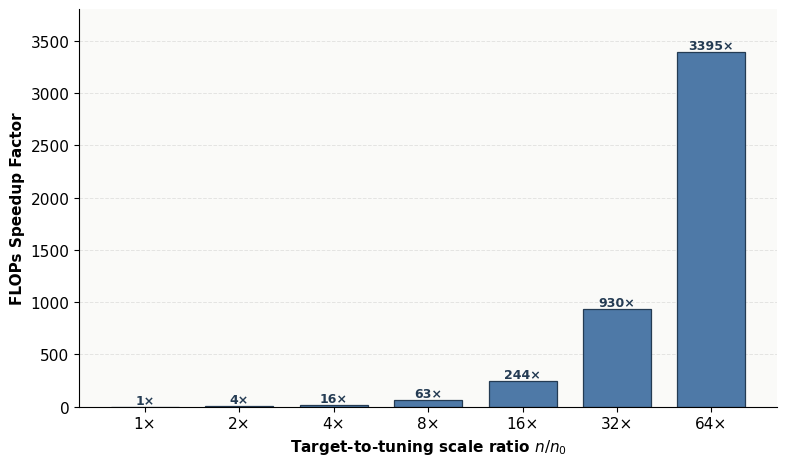

In [25]:
positions = np.arange(len(ratio_considered_resnet))
colors = ["#4E79A7"] * len(ratio_considered_resnet)

plt.rcParams.update(
    {
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

fig, ax = plt.subplots(figsize=(8, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAF8")

bars = ax.bar(
    positions,
    normalized_resnet_flops_array,
    width=0.72,
    color=colors,
    edgecolor="#243B53",
    linewidth=0.9,
)

for x, bar, value in zip(positions, bars, normalized_resnet_flops_array):
    ax.text(
        x,
        bar.get_height() + 0.3,
        f"{value:.0f}×",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#243B53",
    )

ax.set_xticks(positions)
ax.set_xticklabels([f"{r}×" for r in ratio_considered_resnet])

ax.set_xlabel("Target-to-tuning scale ratio $n/n_0$", fontweight="bold")
ax.set_ylabel("FLOPs Speedup Factor", fontweight="bold")

ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, normalized_resnet_flops_array.max() * 1.12)

plt.tight_layout()

plt.savefig("resnet18-flops.pdf")

plt.show()

In [28]:
## Summary: FLOPs Speedup Across Models (LaTeX)

# Experiment-specific compression ratios
mlp_r_exp = 5  # MLP: hidden_dim 2000→400
resnet_r_exp = 4  # ResNet: wm 1→0.25
gpt2_r_exp = 2  # GPT-2: Q 64→32

# MLP speedup at r=5
mlp_flops_at_exp = estimate_mlp_flops(
    input_dim=mlp_config["input_dim"],
    hidden_dim=mlp_config["hidden_dim"] // mlp_r_exp,
    output_dim=mlp_config["output_dim"],
    num_layers=mlp_config["num_layers"],
)
mlp_speedup = mlp_flops_list[0] / mlp_flops_at_exp

# ResNet speedup at r=4
resnet_speedup = resnet_flops_list[0] / estimate_resnet18_flops(wm=1.0 / resnet_r_exp, H=32, W=32, num_classes=100)

# GPT-2 speedup at r=2
_L = small_config["n_layer"]
_H = small_config["n_head"]
_Q0 = small_config["n_embd"] // _H
_T = 1024
_tmp_Q = _Q0 // gpt2_r_exp
_tmp_E = _tmp_Q * _H
_N_exp = gpt_params(seq_len=_T, vocab_size=50257, d_model=_tmp_E, num_heads=_H, num_layers=_L)
gpt2_flops_at_exp = estimate_flops(N=_N_exp, L=_L, H=_H, Q=_tmp_Q, T=_T)
gpt2_speedup = flops_array[0] / gpt2_flops_at_exp

rows = {
    r"MLP": [1.0, mlp_speedup],
    r"ResNet": [1.0, resnet_speedup],
    r"GPT-2": [1.0, gpt2_speedup],
}

df = pd.DataFrame(rows, index=[r"$1$", r"Experiment"])

# Column headers with per-model ratios as a subline
col_headers_map = {
    r"MLP": (r"MLP", mlp_r_exp),
    r"ResNet": (r"ResNet", resnet_r_exp),
    r"GPT-2": (r"GPT-2", gpt2_r_exp),
}
col_headers = " & ".join(r"\textbf{" + name + r"} \\ \small{$(n/n_0\!=\!" + str(r) + r")$}" for name, r in col_headers_map.values())
n_cols = len(df.columns)

lines = []
lines.append(r"\begin{table}[h]")
lines.append(r"  \centering")
lines.append(r"  \begin{tabular}{l" + "r" * n_cols + r"}")
lines.append(r"  \toprule")
lines.append(r"   & " + col_headers + r" \\")
lines.append(r"  \midrule")
for idx, row in df.iterrows():
    vals = " & ".join([f"${v:.1f}\\times$" for v in row])
    lines.append(f"  {idx} & {vals} \\\\")
lines.append(r"  \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(
    r"  \caption{Tuning-cost FLOPs speedup of hyperparameter transfer vs.\ tuning the "
    r"full-scale target model directly, at each model's experiment compression ratio. "
    r"Speedup $= \mathcal{F}(n)\,/\,\mathcal{F}(n_0)$.}"
)
lines.append(r"  \label{tab:flops-speedup}")
lines.append(r"\end{table}")

latex = "\n".join(lines)
print(latex)

\begin{table}[h]
  \centering
  \begin{tabular}{lrrr}
  \toprule
   & \textbf{MLP} \\ \small{$(n/n_0\!=\!5)$} & \textbf{ResNet} \\ \small{$(n/n_0\!=\!4)$} & \textbf{GPT-2} \\ \small{$(n/n_0\!=\!2)$} \\
  \midrule
  $1$ & $1.0\times$ & $1.0\times$ & $1.0\times$ \\
  Experiment & $23.6\times$ & $15.8\times$ & $2.8\times$ \\
  \bottomrule
  \end{tabular}
  \caption{Tuning-cost FLOPs speedup of hyperparameter transfer vs.\ tuning the full-scale target model directly, at each model's experiment compression ratio. Speedup $= \mathcal{F}(n)\,/\,\mathcal{F}(n_0)$.}
  \label{tab:flops-speedup}
\end{table}
